## 📊 A— Correlação

### Explicação  da Teoria
A **Regressão Linear** busca encontrar a melhor reta ($y = ax + b$) que descreve a relação entre duas variáveis. 

* **`scipy.stats.linregress`**: Função que utiliza o método dos mínimos quadrados. Ela retorna:
    * **Coeficiente Angular ($a$)**: Inclinação da reta. Indica a taxa de variação de $y$ em relação a $x$.
    * **Intercepto ($b$)**: Onde a reta cruza o eixo $y$.
    * **p-value**: Testa a hipótese nula de que a inclinação é zero ($a=0$). Se $p < 0.05$, rejeitamos a hipótese nula, indicando uma relação estatisticamente significativa.
* **Covariância**: Mede a variância conjunta de duas variáveis. Se for positiva, ambas tendem a crescer juntas.

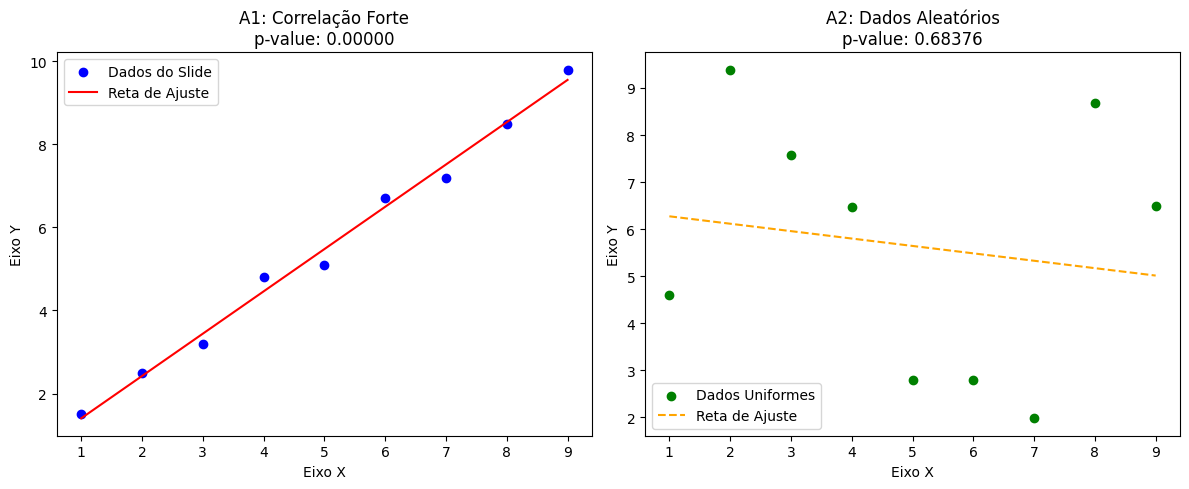

Covariância A1: 7.64
Covariância A2: -1.18


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

#GRÁFICO 1
x1 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
y1 = np.array([1.5, 2.5, 3.2, 4.8, 5.1, 6.7, 7.2, 8.5, 9.8]) # Correlação forte

#GRAFICO 2: DADOS ALEATÓRIOS 
np.random.seed(42) 
x2 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
y2 = np.random.uniform(low=min(y1), high=max(y1), size=9)

#calculos via linregress
slope1, intercept1, r1, p1, std_err1 = stats.linregress(x1, y1)
slope2, intercept2, r2, p2, std_err2 = stats.linregress(x2, y2)

#calculo da covariancia
cov1 = np.cov(x1, y1)[0, 1]
cov2 = np.cov(x2, y2)[0, 1]

#plotagem
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1
ax1.scatter(x1, y1, color='blue', label='Dados do Slide')
ax1.plot(x1, slope1*x1 + intercept1, color='red', label='Reta de Ajuste')
ax1.set_title(f"A1: Correlação Forte\np-value: {p1:.5f}")
ax1.set_xlabel("Eixo X"); ax1.set_ylabel("Eixo Y"); ax1.legend()

#plot 2
ax2.scatter(x2, y2, color='green', label='Dados Uniformes')
ax2.plot(x2, slope2*x2 + intercept2, color='orange', linestyle='--', label='Reta de Ajuste')
ax2.set_title(f"A2: Dados Aleatórios\np-value: {p2:.5f}")
ax2.set_xlabel("Eixo X"); ax2.set_ylabel("Eixo Y"); ax2.legend()

plt.tight_layout()
plt.show()

print(f"Covariância A1: {cov1:.2f}")
print(f"Covariância A2: {cov2:.2f}")

## 📈 B — Estimando um Intervalo de Confiança para a Média

### Definição e Interpretação
O **Intervalo de Confiança (IC)** é um intervalo estimado onde a média real da população deve estar, com uma determinada probabilidade.

**Fórmula utilizada:**
$$IC = \bar{x} \pm t_{\alpha/2} \cdot \left(\frac{s}{\sqrt{n}}\right)$$

* **Comparação entre níveis:** * Um **IC de 99%** é mais largo que um de **90%**, pois para aumentar a certeza de que o valor real está no intervalo, precisamos aumentar a margem de erro.

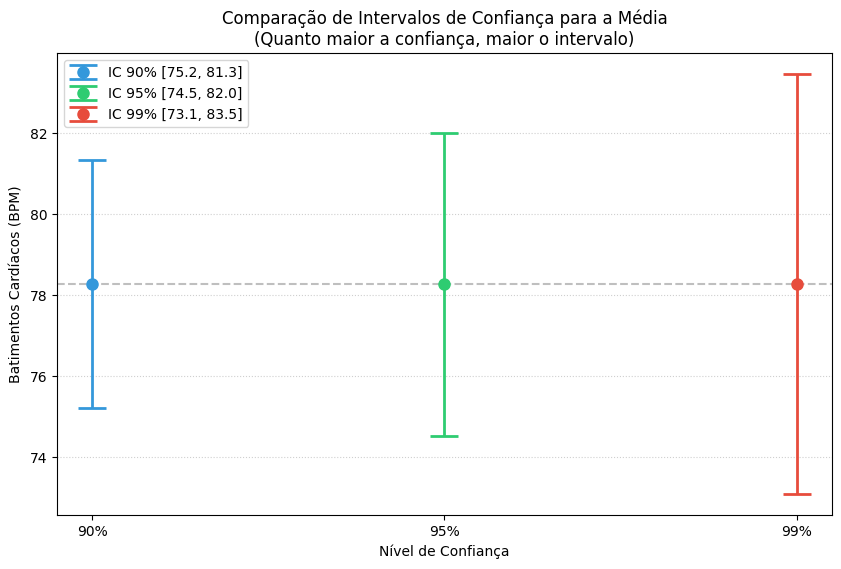

Média Amostral: 78.27
IC 90%: 75.19 até 81.34
IC 95%: 74.53 até 82.01
IC 99%: 73.07 até 83.46


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

dados = np.array([85, 71, 78, 92, 69, 75, 80, 88, 72, 79, 81, 74, 83, 70, 77])

media = np.mean(dados)
std_err = st.sem(dados) #erro padrao da media
n = len(dados)

#niveis de confianca solicitados
niveis = [0.90, 0.95, 0.99]
cores = ['#3498db', '#2ecc71', '#e74c3c'] # Cores acadêmicas

plt.figure(figsize=(10, 6))

#gera intervalos e plota
for i, conf in enumerate(niveis):
    intervalo = st.t.interval(conf, df=n-1, loc=media, scale=std_err)
    margem = intervalo[1] - media
    
    #plotagem com erro
    plt.errorbar(i, media, yerr=[[margem], [margem]], fmt='o', color=cores[i], 
                 capsize=10, capthick=2, elinewidth=2, markersize=8,
                 label=f'IC {int(conf*100)}% [{intervalo[0]:.1f}, {intervalo[1]:.1f}]')

plt.axhline(media, color='gray', linestyle='--', alpha=0.5) # Linha da média central
plt.xticks(range(len(niveis)), ['90%', '95%', '99%'])
plt.title('Comparação de Intervalos de Confiança para a Média\n(Quanto maior a confiança, maior o intervalo)', fontsize=12)
plt.ylabel('Batimentos Cardíacos (BPM)')
plt.xlabel('Nível de Confiança')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()

plt.show()

#exibicao dos valores para interpretacao teorica
print(f"Média Amostral: {media:.2f}")
for conf in niveis:
    inter = st.t.interval(conf, df=n-1, loc=media, scale=std_err)
    print(f"IC {int(conf*100)}%: {inter[0]:.2f} até {inter[1]:.2f}")

## 🧪 C — p-value em um Teste de Hipótese

### Metodologia
* **Hipótese Nula ($H_0$):** Não existe diferença significativa entre as médias do Grupo Controle e do Grupo Teste.
* **Hipótese Alternativa ($H_1$):** Existe uma diferença significativa.

O **p-value** indica a probabilidade de observar os resultados obtidos (ou algo mais extremo) assumindo que $H_0$ é verdadeira. Se $p < 0.05$, o resultado é considerado improvável de ter ocorrido por acaso, logo, rejeitamos $H_0$.

In [53]:
 # Dados simulados (Ex: Notas de alunos com e sem monitoria)
controle = np.random.normal(7.0, 1.0, 30)
teste = np.random.normal(7.8, 1.0, 30)

t_stat, p_val = st.ttest_ind(controle, teste)

print(f"Estatística T: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

alpha = 0.05
if p_val < alpha:
    print("Resultado: Rejeitamos a hipótese nula (H0). Há diferença significativa.")
else:
    print("Resultado: Não há evidências para rejeitar H0.")

Estatística T: -1.8588
p-value: 0.0681
Resultado: Não há evidências para rejeitar H0.
